# liu2023 — Liu et al. (2023) ReLU NNs, Polyhedra & PH

Binary ReLU activation patterns partition input space into polyhedral regions; PH on the Hamming distance between regions recovers the **loops of the data manifold**.


## What the paper does

A ReLU network partitions input space into **polyhedral regions** — one per distinct binary activation pattern (which units are on/off).  Each input lands in one region; treating the unique patterns as points with a **Hamming distance** and running persistent homology reads off the topology of how those regions tile the data.

**Methodology:** trained ReLU net → per-input binary activation pattern → Hamming distance over unique regions → VR PH (`H0`,`H1`).

**Expected result:** the number of persistent `H1` generators recovers the number of **loops** in the underlying data manifold (their Sec. 5) — feed data on a circle (one loop) and a single dominant `H1` generator should appear, well above the noise.


## Dataset & model in the paper

- **arXiv:** [https://arxiv.org/abs/2306.17418](https://arxiv.org/abs/2306.17418)
- **Venue:** TAG-ML 2023 (PMLR 221)
- **Datasets used:** Small synthetic 2-D classification problems with known homology (annulus, two-moons).
- **Models used:** Small ReLU MLPs trained to classification.
- **Headline result to aim for:** PH H1 generators on the polyhedral decomposition graph correctly count the number of loops in the underlying data manifold (their Sec. 5 experiments).
- **Reference code:** [https://github.com/cglrtrgy/GoL_Toolbox](https://github.com/cglrtrgy/GoL_Toolbox)

To reproduce paper numbers, replace the synthetic-data cell below with the real model snapshot / activations / trajectory.  Everything else in the notebook stays the same.


**This notebook runs on real data.**  A ReLU MLP is trained on a 2-D dataset with *known* topology (a circle, β1 = 1) and its polyhedral decomposition is analysed.


In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))  # make `paper_reproduce` importable
import numpy as np
import matplotlib.pyplot as plt
import torch
from tanc import TDAPipeline
from paper_reproduce._torch_setup import (
    load_mnist, load_fashion_mnist, load_cifar10, load_cifar100,
    SmallMLP, SmallCNN, CNN_FCN, CNN_FCN2, VGGLike, train_briefly, extract_snapshot, pick_device,
)
np.random.seed(0); torch.manual_seed(0)
DEVICE = pick_device()                      # 'cuda' → 'mps' (Apple GPU) → 'cpu'


## 1. A dataset with known topology — a circle (β₁ = 1)

Points sampled on a noisy circle form a single 1-D loop.  The label is a half-plane split (`sin θ > 0`) so the decision boundary crosses the loop and the network must carve regions around it.


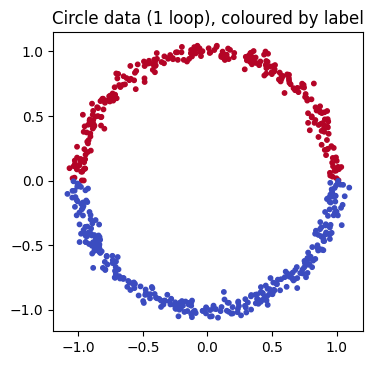

In [2]:
rng = np.random.default_rng(0)
N = 600
theta = rng.uniform(0, 2 * np.pi, N)
r = 1.0 + 0.04 * rng.standard_normal(N)
X = np.column_stack([r * np.cos(theta), r * np.sin(theta)]).astype(np.float32)
y = (np.sin(theta) > 0).astype(np.int64)

plt.figure(figsize=(4, 4))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', s=10)
plt.gca().set_aspect('equal'); plt.title('Circle data (1 loop), coloured by label')
plt.show()


## 2. Train a ReLU MLP and read its activation patterns

For each input we take the sign pattern of the hidden ReLU units (on/off) — its polyhedral region.  We extract the hidden layers' activations explicitly and binarise them, **excluding the output layer** (the method is defined on the hidden ReLU units).


In [3]:
model = SmallMLP(input_dim=2, hidden_dims=[64, 64], output_dim=2)
train_briefly(model, X, y, X, y, epochs=60,
              aspects=['activations'], device=DEVICE, verbose=False)

snap = extract_snapshot(model.to('cpu').eval(), X,
                        aspects=['activations'], layer_selection='all_linear')
acts = snap.all_activation_matrices()           # [fc1, fc2, output]
patterns = np.concatenate([(a > 0).astype(int) for a in acts[:-1]], axis=1)
print(f'pattern matrix {patterns.shape} -> '
      f'{len(np.unique(patterns, axis=0))} unique polyhedral regions')


pattern matrix (600, 128) -> 141 unique polyhedral regions


## 3. Visualise the polyhedral decomposition in input space

Because the input is 2-D we can *see* the regions: evaluate the ReLU patterns on a dense grid — each distinct pattern is one linear (polyhedral) region, and the boundaries are the network's piecewise-linear cuts.  The data loop (points) threads through these polygons — exactly the structure `H1` measures.


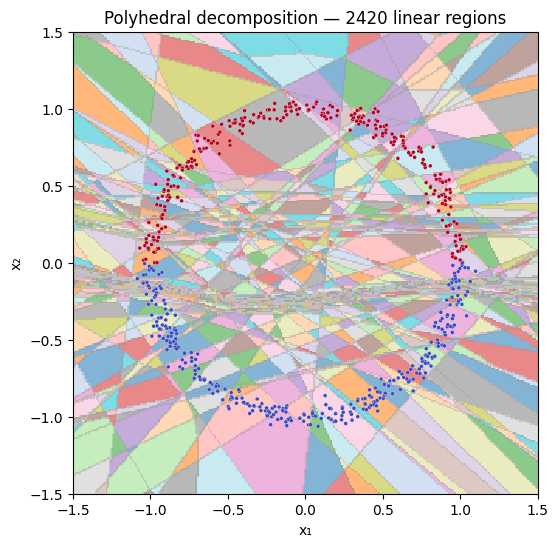

In [4]:
from tanc.visualisation import plot_polyhedral_regions

g = 300
xs = np.linspace(-1.5, 1.5, g)
xx, yy = np.meshgrid(xs, xs)
grid = np.column_stack([xx.ravel(), yy.ravel()]).astype(np.float32)
snap_g = extract_snapshot(model, grid, aspects=['activations'],
                          layer_selection='all_linear')
grid_patterns = np.concatenate(
    [(a > 0).astype(int) for a in snap_g.all_activation_matrices()[:-1]], axis=1)
fig = plot_polyhedral_regions(xx, yy, grid_patterns, points=X, point_labels=y)
plt.show()


## 4. Persistent homology of the polyhedral decomposition


TopoResult(tool='ph')
  paper       : Liu et al. (2023)
  data        : ph_result (H0: 141 bars, H1: 10 bars)
  statistics  : H0_total_persistence, H0_persistence_norm, H0_betti_curve, H0_persistence_entropy, H1_total_persistence, H1_persistence_norm (+2 more)
  plots       :
    .plot('diagram') — Birth-vs-death scatter of persistence pairs.
    .plot('barcode') — Horizontal bars from birth to death, sorted by birth.
    .plot('betti_curve') — Step function of Betti_d across the filtration range.
  config keys : max_dim, coeff, backend, input_type, matrix_type, epsilon, k, filtration_schedule (+1 more)


"TopoResult(tool='ph')\n  paper       : Liu et al. (2023)\n  data        : ph_result (H0: 141 bars, H1: 10 bars)\n  statistics  : H0_total_persistence, H0_persistence_norm, H0_betti_curve, H0_persistence_entropy, H1_total_persistence, H1_persistence_norm (+2 more)\n  plots       :\n    .plot('diagram') — Birth-vs-death scatter of persistence pairs.\n    .plot('barcode') — Horizontal bars from birth to death, sorted by birth.\n    .plot('betti_curve') — Step function of Betti_d across the filtration range.\n  config keys : max_dim, coeff, backend, input_type, matrix_type, epsilon, k, filtration_schedule (+1 more)"

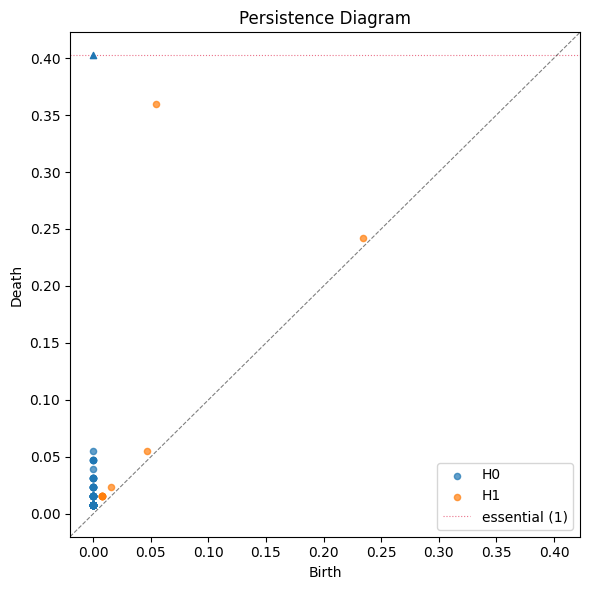

In [5]:
pipe = TDAPipeline.from_paper("liu2023")
result, fig = pipe.reproduce(patterns)
result.describe()


## 5. The data's loop is recovered by H1

A single `H1` generator should stand out far above the rest — that is the circle's one loop, found purely from the network's region structure.


top H1 lifetimes: [0.305 0.008 0.008 0.008 0.008 0.008]
dominant generator = 0.305, 39.0x the next -> the 1 loop of the circle


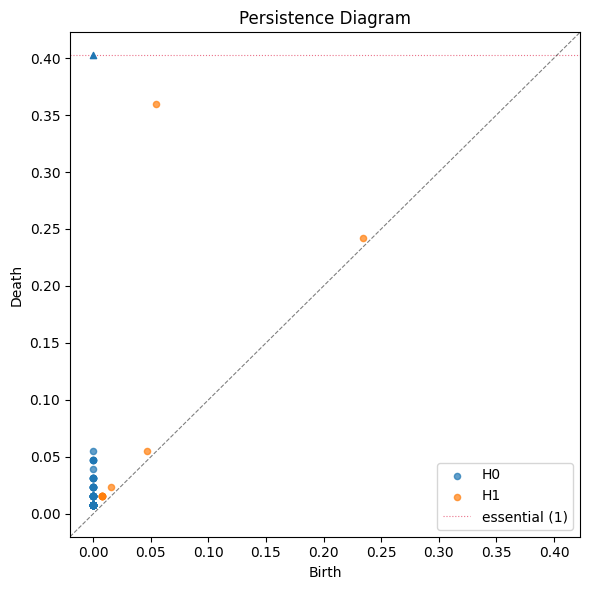

In [6]:
d1 = result.diagram(1)
life = np.sort(d1[:, 1] - d1[:, 0])[::-1]
print('top H1 lifetimes:', np.round(life[:6], 3))
print(f'dominant generator = {life[0]:.3f}, '
      f'{life[0] / life[1]:.1f}x the next -> the 1 loop of the circle')
fig = result.plot('diagram', dims=[0, 1])


## 6. How the polyhedral regions relate to the task

Within a single region every hidden ReLU is fixed on/off, so the network is an **affine** map there — the classifier is **piecewise-linear**.  Its **decision boundary** (bold black below) is therefore a polyline: a straight segment inside each region it crosses, bending only at region boundaries.  So the net *spends* regions where the task needs a curvy boundary — few large regions in easy areas, many small ones hugging a hard boundary.  The decomposition is the network's piecewise-linear scaffolding for the task; section 4's PH then measures the *topology* of how those regions tile the data.


In [7]:
from sklearn.datasets import make_moons

def make_2d(kind, n=600, seed=0):
    '''Four 2-D tasks with different boundary shapes.'''
    rng = np.random.default_rng(seed)
    if kind == 'circle':
        th = rng.uniform(0, 2*np.pi, n); r = 1 + 0.04*rng.standard_normal(n)
        X = np.c_[r*np.cos(th), r*np.sin(th)]; y = (np.sin(th) > 0).astype(int)
    elif kind == 'moons':
        X, y = make_moons(n, noise=0.08, random_state=seed); X = (X-X.mean(0))/X.std(0)
    elif kind == 'xor':
        X = rng.uniform(-1.4, 1.4, (n, 2)); y = ((X[:,0] > 0) ^ (X[:,1] > 0)).astype(int)
    elif kind == 'spiral':
        k = n//2; t = np.sqrt(rng.uniform(0.04, 1, k))*2.8*np.pi
        A = np.c_[t*np.cos(t), t*np.sin(t)]; B = np.c_[t*np.cos(t+np.pi), t*np.sin(t+np.pi)]
        X = np.vstack([A, B])/9; y = np.r_[np.zeros(k), np.ones(k)].astype(int)
    return X.astype(np.float32), y.astype(np.int64)

def decomposition(model, X, g=220):
    '''Grid ReLU patterns + predicted class over the input window.'''
    model = model.to('cpu').eval()
    lim = float(np.abs(X).max() * 1.15); xs = np.linspace(-lim, lim, g)
    xx, yy = np.meshgrid(xs, xs)
    grid = np.column_stack([xx.ravel(), yy.ravel()]).astype(np.float32)
    s = extract_snapshot(model, grid, aspects=['activations'], layer_selection='all_linear')
    pat = np.concatenate([(a > 0).astype(int) for a in s.all_activation_matrices()[:-1]], axis=1)
    with torch.no_grad():
        pred = model(torch.from_numpy(grid)).argmax(1).numpy()
    return xx, yy, pat, pred


## 7. A gallery of 2-D tasks — decomposition + persistence diagram

Each row: **left** — the polyhedral regions, their boundaries, the bold **decision boundary** and the data; **right** — the **persistence diagram** of that network's activation patterns.  Watch how regions crowd where the boundary curves, and note that only the **circle** shows a prominent off-diagonal `H1` point (its loop) — the contractible moons/xor/spiral keep their `H1` near the diagonal (noise).


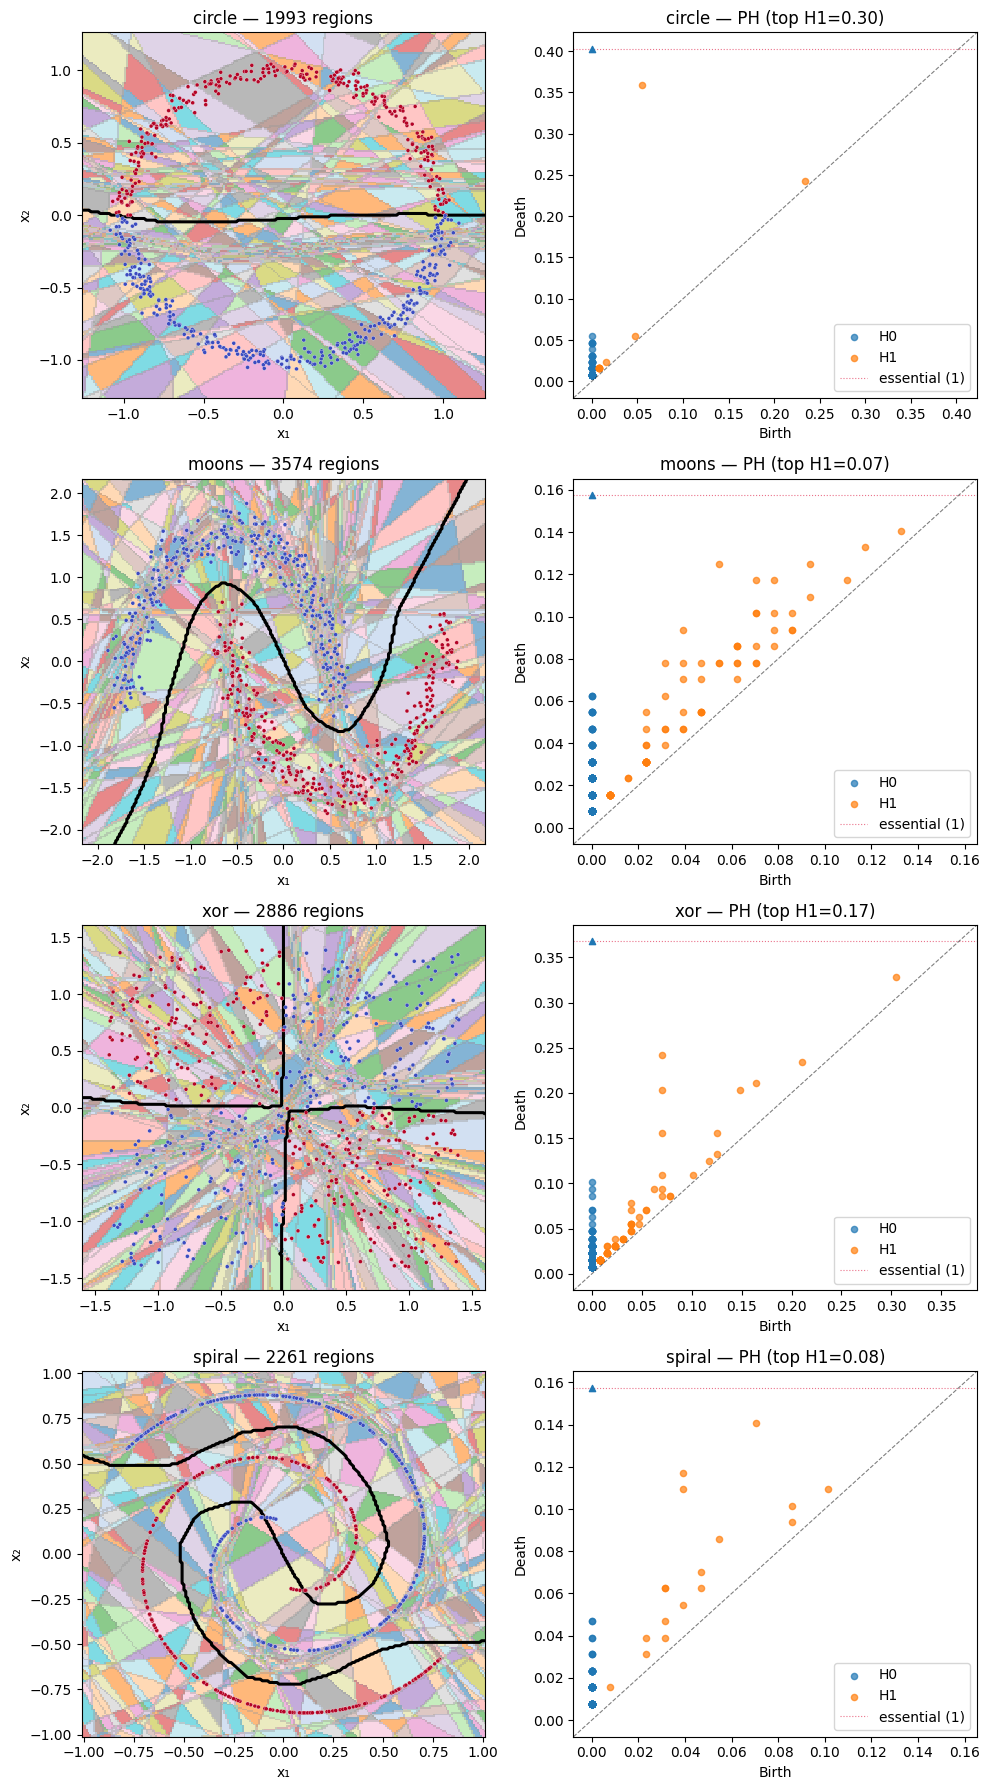

In [8]:
pipe = TDAPipeline.from_paper("liu2023")
fig, axes = plt.subplots(4, 2, figsize=(10, 18))
for (ax_dec, ax_dgm), kind in zip(axes, ['circle', 'moons', 'xor', 'spiral']):
    torch.manual_seed(0)
    Xk, yk = make_2d(kind)
    mk = SmallMLP(2, [64, 64], int(yk.max()) + 1)
    train_briefly(mk, Xk, yk, Xk, yk, epochs=60,
                  aspects=['activations'], device=DEVICE, verbose=False)
    # left: polyhedral decomposition + decision boundary
    xx, yy, pat, pred = decomposition(mk, Xk)
    plot_polyhedral_regions(xx, yy, pat, points=Xk, point_labels=yk, decision=pred,
                            ax=ax_dec, title=f'{kind} — {len(np.unique(pat, axis=0))} regions')
    # right: persistence diagram of the data-point activation patterns
    sd = extract_snapshot(mk.to('cpu').eval(), Xk,
                          aspects=['activations'], layer_selection='all_linear')
    dpat = np.concatenate([(a > 0).astype(int) for a in sd.all_activation_matrices()[:-1]], axis=1)
    res = pipe.fit(dpat)
    d1 = res.diagram(1)
    top = float(np.sort(d1[:, 1] - d1[:, 0])[::-1][0]) if len(d1) else 0.0
    res.plot('diagram', dims=[0, 1], ax=ax_dgm, title=f'{kind} — PH (top H1={top:.2f})')
fig.tight_layout(); plt.show()


## Notes & gaps

* Implements the method as described, on a **real ReLU network** over data with known topology: a 1-loop circle yields one dominant `H1` generator above the noise floor.
* **Regions ↔ task:** the classifier is affine within each region, so the decision boundary is piecewise-linear and regions concentrate where it must curve (gallery).  Clean `H1` loop-counting (section 5) only applies when the *data manifold itself* has loops — moons/xor/spiral are contractible, so their `H1` is noise despite rich region structure.
* Loop-counting is sensitive to the data/task/architecture (the network must form regions that wrap the loop — a *linearly separable* task won't).  Two well-separated circles, for instance, are split linearly and show no loops; the paper's Sec. 5 uses carefully designed manifolds.
* Region-count evolution over training: capture a `view` and use `plot_ph_statistic_trajectory(view, stat='total_persistence')`.


## Deviations from the paper

Everything this notebook does differently from the source, and why. An empty
table below means the construction follows the paper as written — that is a
claim, not an omission. Scale always differs; see the last row.

| aspect | the paper | this notebook | why it matters |
|---|---|---|---|
| Hamming scale | Hamming distance between binary vectors (bit count) | the same distance as a fraction of the bit length | a monotone rescaling: persistence is identical up to a constant factor |
| scale | the paper's full experimental setup | a smaller model, fewer samples, fewer epochs | to keep the notebook runnable in minutes; expect weaker effects than published |
